# F1 Lap Time Prediction

## Preprocessing

In [283]:
import pandas as pd

df = pd.read_csv("laps_2021.csv")
df.head()

,Race,Round,Driver,Team,LapNumber,Position,Stint,Compound,TyreLife,FreshTyre,...,BrakePercent,AvgRPM,AvgGear,DRSUsagePercent,AirTemp,TrackTemp,Humidity,Pressure,WindDirection,WindSpeed
0,Bahrain Grand Prix,1,HAM,Mercedes,1.0,2.0,1.0,MEDIUM,4.0,False,...,23.991935,9222.024194,3.933468,100.000000,20.538346,27.62782,54.517293,1014.910526,63.887218,0.887218
1,Bahrain Grand Prix,1,HAM,Mercedes,2.0,2.0,1.0,MEDIUM,5.0,False,...,26.858108,8643.518581,3.569257,100.000000,20.538346,27.62782,54.517293,1014.910526,63.887218,0.887218
2,Bahrain Grand Prix,1,HAM,Mercedes,4.0,2.0,1.0,MEDIUM,7.0,False,...,23.357664,9794.751825,4.715328,100.000000,20.538346,27.62782,54.517293,1014.910526,63.887218,0.887218
3,Bahrain Grand Prix,1,HAM,Mercedes,5.0,2.0,1.0,MEDIUM,8.0,False,...,25.458716,9868.385321,4.750000,40.825688,20.538346,27.62782,54.517293,1014.910526,63.887218,0.887218
4,Bahrain Grand Prix,1,HAM,Mercedes,6.0,2.0,1.0,MEDIUM,9.0,False,...,20.997375,10072.569554,5.288714,0.000000,20.538346,27.62782,54.517293,1014.910526,63.887218,0.887218


In [284]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23303 entries, 0 to 23302
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Race             23303 non-null  object 
 1   Round            23303 non-null  int64  
 2   Driver           23303 non-null  object 
 3   Team             23303 non-null  object 
 4   LapNumber        23303 non-null  float64
 5   Position         23303 non-null  float64
 6   Stint            23303 non-null  float64
 7   Compound         23303 non-null  object 
 8   TyreLife         23303 non-null  float64
 9   FreshTyre        23303 non-null  bool   
 10  TrackStatus      23303 non-null  int64  
 11  Sector1Time      22871 non-null  float64
 12  Sector2Time      23297 non-null  float64
 13  Sector3Time      23298 non-null  float64
 14  LapTime          23303 non-null  float64
 15  AvgSpeed         23303 non-null  float64
 16  MaxSpeed         23303 non-null  float64
 17  AvgThrottle 

In [285]:
df.shape

(23303, 28)

In [286]:
# dropping all rows with n ull values since the number of null values is very very less

df = df.dropna()
df.shape

(22870, 28)

In [287]:
# since sector timings cause data leakage in case for lap time prediction we eliminate all three sector timing columns

df = df.drop(columns=["Sector1Time", "Sector2Time", "Sector3Time"])

In [288]:
# convert fresh tyre column from true false to 0 and 1

df["FreshTyre"] = df["FreshTyre"].astype(int)
df["FreshTyre"].head()

1    0
2    0
3    0
4    0
5    0
Name: FreshTyre, dtype: int64

In [289]:
# we drop round since its the same as race data

df = df.drop(columns=["Round"])

In [290]:
# we drop a few telemtry data as they are directly retrieved from lap info and might leak information like how sector timings might have done

leak_telemetry_data = [
    "AvgSpeed",
    "MaxSpeed",
    "AvgThrottle",
    "BrakePercent",
    "AvgRPM",
    "AvgGear",
    "DRSUsagePercent"
]
df = df.drop(columns=leak_telemetry_data)

In [291]:
# we perform one hot encoding to all categorical data columns since those information are important too

cat_cols = ["Race", "Driver", "Team", "Compound"]
df = pd.get_dummies(df, columns=cat_cols, dtype=int)

In [292]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22870 entries, 1 to 23302
Data columns (total 70 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   LapNumber                       22870 non-null  float64
 1   Position                        22870 non-null  float64
 2   Stint                           22870 non-null  float64
 3   TyreLife                        22870 non-null  float64
 4   FreshTyre                       22870 non-null  int64  
 5   TrackStatus                     22870 non-null  int64  
 6   LapTime                         22870 non-null  float64
 7   AirTemp                         22870 non-null  float64
 8   TrackTemp                       22870 non-null  float64
 9   Humidity                        22870 non-null  float64
 10  Pressure                        22870 non-null  float64
 11  WindDirection                   22870 non-null  float64
 12  WindSpeed                       22870

In [293]:
# train test split

X = df.drop("LapTime", axis=1)
y = df["LapTime"] # to be predicted by model

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [294]:
# to feature scale only the numerical columns and not the one hot encoded columns or bool columns

# numerical_cols = [
#     "LapNumber",
#     "Position",
#     "Stint",
#     "TyreLife",
#     "TrackStatus",
#     "AvgSpeed",
#     "MaxSpeed",
#     "AvgThrottle",
#     "BrakePercent",
#     "AvgRPM",
#     "AvgGear",
#     "DRSUsagePercent",
#     "AirTemp",
#     "TrackTemp",
#     "Humidity",
#     "Pressure",
#     "WindDirection",
#     "WindSpeed"
# ]

numerical_cols = [
    "LapNumber",
    "Position",
    "Stint",
    "TyreLife",
    "TrackStatus",
    "AirTemp",
    "TrackTemp",
    "Humidity",
    "Pressure",
    "WindDirection",
    "WindSpeed"
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [295]:
X_train.head()

,LapNumber,Position,Stint,TyreLife,FreshTyre,TrackStatus,AirTemp,TrackTemp,Humidity,Pressure,...,Team_Haas F1 Team,Team_McLaren,Team_Mercedes,Team_Red Bull Racing,Team_Williams,Compound_HARD,Compound_INTERMEDIATE,Compound_MEDIUM,Compound_SOFT,Compound_WET
19918,-0.045376,1.522673,1.641069,-1.286008,1,-0.086671,0.085827,1.578021,0.244714,-0.968681,...,0,0,0,0,0,1,0,0,0,0
7634,0.719632,0.968338,-0.165272,0.075922,1,-0.086671,0.572794,-0.069770,0.148264,-0.365061,...,0,0,0,0,0,0,0,1,0,0
16085,-0.810384,-0.140331,-1.068442,0.075922,1,-0.086671,-1.549700,-1.789729,2.436413,0.454622,...,0,0,0,0,0,0,1,0,0,0
20192,-0.373237,1.522673,1.641069,-0.410481,1,-0.086671,0.085827,1.578021,0.244714,-0.968681,...,0,0,0,0,1,1,0,0,0,0
21015,0.118554,-0.694665,-0.165272,-0.702324,1,-0.086671,0.819007,-0.536437,1.257093,0.560225,...,0,1,0,0,0,1,0,0,0,0


In [296]:
# this is just for future uses of other f1 projects in case

import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Model Building

### Neural Network Regression Model using Dense layers

In [297]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

f1_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

In [298]:
f1_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [299]:
# this is to avoid overfitting due to excessive epochs 

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [300]:
# train run

history = f1_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop], # stop early once validation loss stops improving, keep best weights
    verbose=1 # this is just to print epoch information at each epoch
)

Epoch 1/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 1s 829us/step - loss: 2717.6445 - mae: 36.3746 - val_loss: 68.9125 - val_mae: 4.6996
Epoch 2/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - loss: 70.1717 - mae: 4.6393 - val_loss: 55.4069 - val_mae: 4.1057
Epoch 3/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 592us/step - loss: 61.1097 - mae: 4.3906 - val_loss: 51.5211 - val_mae: 4.0176
Epoch 4/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 586us/step - loss: 52.2951 - mae: 4.0482 - val_loss: 52.5833 - val_mae: 4.4250
Epoch 5/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - loss: 51.0031 - mae: 4.0340 - val_loss: 46.1517 - val_mae: 3.7713
Epoch 6/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 539us/step - loss: 43.5105 - mae: 3.6659 - val_loss: 43.7606 - val_mae: 3.6805
Epoch 7/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 537us/step - loss: 44.0379 - mae: 3.7611 - val_loss: 42.3125 - val_mae: 3.5973
Epoch 8/50
458/458 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step - loss: 40.2891 - mae: 3.5548 - val_loss: 42.8121 - val_mae: 3.6393
Epoch 9/50
458/458 ━━

In [301]:
test_loss, test_mae = f1_model.evaluate(X_test, y_test)

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f} seconds")

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 345us/step - loss: 28.9625 - mae: 2.8774
Test Loss (MSE): 29.9869
Test MAE: 2.8585 seconds


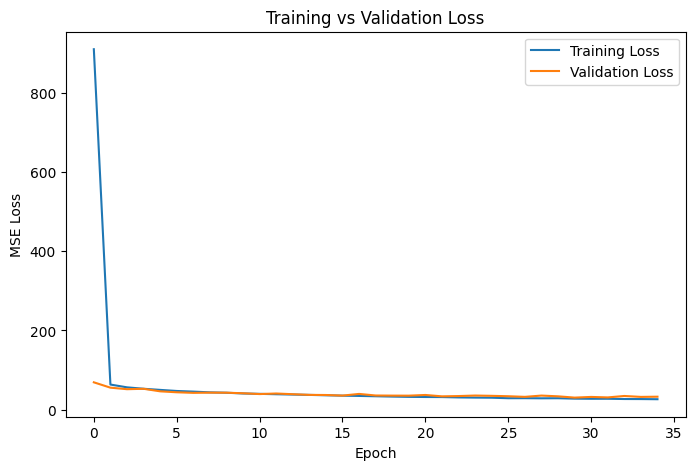

In [302]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

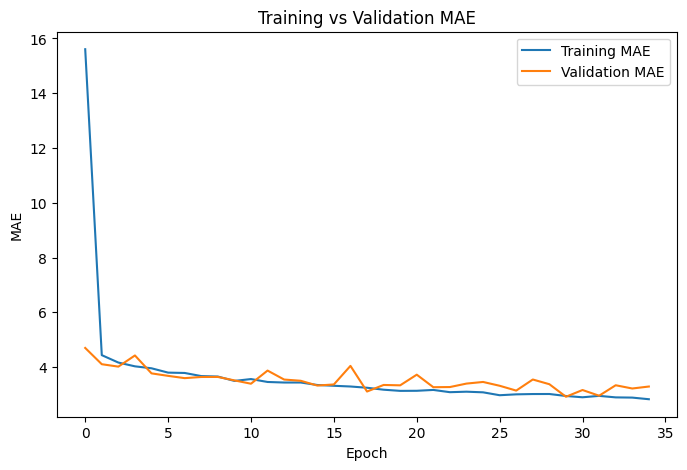

In [303]:
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.show()

In [304]:
from sklearn.metrics import r2_score

y_pred = f1_model.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 358us/step
R² Score: 0.8358


In [305]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"RMSE: {rmse:.4f} seconds")

RMSE: 5.4760 seconds


In [306]:
# this is model comparison

nn_mae = test_mae
nn_rmse = rmse
nn_r2 = r2

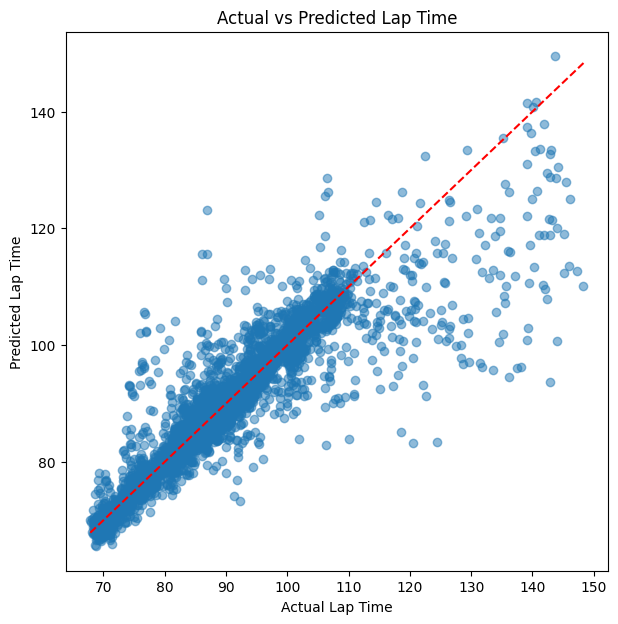

In [307]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Lap Time")
plt.ylabel("Predicted Lap Time")
plt.title("Actual vs Predicted Lap Time")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [308]:
df.corr(numeric_only=True)["LapTime"].sort_values(ascending=False)

LapTime                       1.000000
Race_Azerbaijan Grand Prix    0.300619
Pressure                      0.277688
Humidity                      0.264945
WindSpeed                     0.255289
                                ...   
TyreLife                     -0.270116
Race_Austrian Grand Prix     -0.309428
LapNumber                    -0.311671
Race_Styrian Grand Prix      -0.312267
TrackTemp                    -0.337344
Name: LapTime, Length: 70, dtype: float64

### Linear Regression Model

In [309]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print(f"Linear Regression MAE : {lr_mae:.4f} seconds")
print(f"Linear Regression RMSE: {lr_rmse:.4f} seconds")
print(f"Linear Regression R²  : {lr_r2:.4f}")

Linear Regression MAE : 3.9178 seconds
Linear Regression RMSE: 7.6616 seconds
Linear Regression R²  : 0.6785


In [310]:
# comparing Neural Network model and linear regression model to check if neural network is unnecessarily used while linear regression could have done the task

import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "MAE (s)": [lr_mae, nn_mae],
    "RMSE (s)": [lr_rmse, nn_rmse],
    "R² Score": [lr_r2, nn_r2]
})

comparison

,Model,MAE (s),RMSE (s),R² Score
0,Linear Regression,3.917820,7.661605,0.678531
1,Neural Network,2.858501,5.476026,0.835778


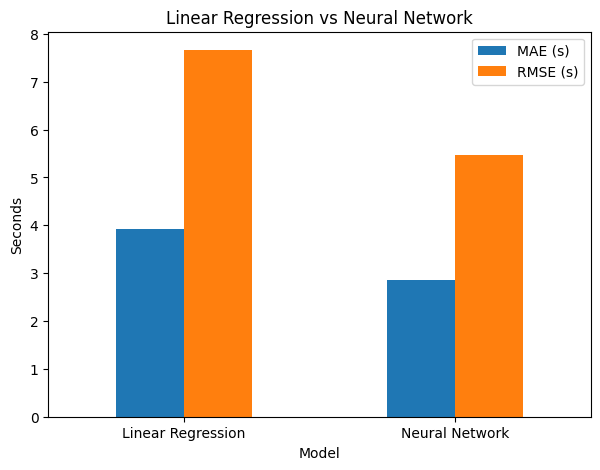

In [311]:
import matplotlib.pyplot as plt

comparison.set_index("Model")[["MAE (s)", "RMSE (s)"]].plot(kind="bar", figsize=(7,5))
plt.ylabel("Seconds")
plt.title("Linear Regression vs Neural Network")
plt.xticks(rotation=0)
plt.show()

Clearly Neural network performs better with better learning than linear regression. Yet the neural network model is not the best hence we can try with ther models.

### Random Forest Model

In [312]:
from sklearn.ensemble import RandomForestRegressor

f1_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [313]:
f1_rf.fit(X_train, y_train)

rf_pred = f1_rf.predict(X_test)

In [314]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE : {rf_mae:.4f} seconds")
print(f"Random Forest RMSE: {rf_rmse:.4f} seconds")
print(f"Random Forest R²  : {rf_r2:.4f}")

Random Forest MAE : 0.8437 seconds
Random Forest RMSE: 2.5065 seconds
Random Forest R²  : 0.9656


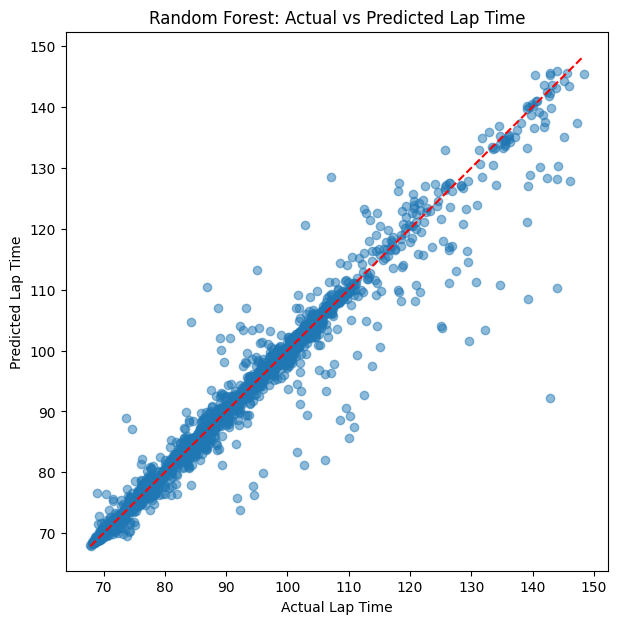

In [315]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Lap Time")
plt.ylabel("Predicted Lap Time")
plt.title("Random Forest: Actual vs Predicted Lap Time")
plt.show()

In [316]:
# feature importance to check which ferature is best used to predict a lap time

import pandas as pd

feature_importance = pd.DataFrame({"Feature": X_train.columns, "Importance": f1_rf.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(15)

,Feature,Importance
9,Pressure,0.297008
5,TrackStatus,0.279909
11,WindSpeed,0.222039
3,TyreLife,0.044826
0,LapNumber,0.042238
10,WindDirection,0.016268
7,TrackTemp,0.014471
8,Humidity,0.012278
1,Position,0.012260
6,AirTemp,0.009531


## Conclusion

Random Forest has given the best results among the three models which we tried. And it clearly performs better than the neural network model which was built only using dense layers.

This model was trained and tested using a random split of laps across all races. 
When I tried testing it on races the model had never seen before (instead of a 
random split), performance dropped drastically. This suggests the model may be partly using 
which race it is as a shortcut for predicting lap time, instead of fully learning 
from tire, weather, and strategy features alone.

A likely next step to fix this would be replacing the race identity columns with 
actual track characteristics (like track length or number of corners), so the 
model learns from real track properties instead of memorizing which race is which.
